# One-dimensional diffusion analysis of the QENS data

Extraction of the water diffusion coefficient in (6,5) and Multi-Chiral single-walled carbon
nanotubes using the **powder-averaged one-dimensional** scattering function of

> K. Hahn, H. Jobic and J. Karger,
> *Investigating one-dimensional diffusion by quasielastic neutron scattering: A theoretical approach*,
> **Phys. Rev. E 59, 6662 (1999)**, Eqs. (20)-(21).

## Why this model

The analysis in the main manuscript used

$$\Gamma(q)=\frac{\hbar D q^{2}}{1+Dq^{2}\tau}$$

which is derived for **isotropic three-dimensional** diffusion. Our samples are bundles of
randomly oriented one-dimensional channels, in which a water molecule can move only along the
nanotube axis. Referee 2 correctly notes that the isotropic form is not justified for such a
sample. Hahn *et al.* derive the scattering function for exactly this geometry: normal diffusion
along one-dimensional channels, powder averaged over channel orientation.

Their result, for a Gaussian one-dimensional self-correlation function with
$\langle r^{2}\rangle = 2Dt$, is

$$S_{3}(Q,\omega)=\frac{1}{4\pi\sqrt{2}\,y\,\omega}
\left[\ln\!\left(\frac{1+y^{2}-\sqrt{2}\,y}{1+y^{2}+\sqrt{2}\,y}\right)
+2\arctan\!\left(1+\sqrt{2}\,y\right)-2\arctan\!\left(1-\sqrt{2}\,y\right)\right]
\qquad (20)$$

$$y=Q\sqrt{D/\omega} \qquad (21)$$

Two features distinguish it from a Lorentzian and both matter for the fitting:

1. **It diverges at $\omega=0$** as $\omega^{-1/2}$. The divergence is integrable, but it means
   the one-dimensional lineshape has a sharp cusp at zero energy transfer that partially mimics an
   elastic line. This is the central point of the Hahn paper.
2. **Its wings fall off as $\omega^{-2}$** with an effective half width
   $\Gamma_{\rm eff}=\hbar Q^{2}D/3$, the factor $1/3$ being the powder average
   $\langle\cos^{2}\theta\rangle$. A single Lorentzian fitted to the same data therefore returns a
   *different* $D$ than Eq. (20) does.

## Units

| quantity | unit used here |
|---|---|
| energy transfer $E$ | $\mu$eV (as stored in the `SOD_data` files) |
| $\omega = E/\hbar$ | ps$^{-1}$, with $\hbar = 658\ \mu$eV$\cdot$ps |
| $Q$ | Angstrom$^{-1}$ |
| $D$ | Angstrom$^2$/ps; multiply by $10^{-4}$ for cm$^2$/s |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from scipy.stats import linregress

try:
    from numpy import trapezoid as trapz
except ImportError:
    from numpy import trapz

plt.rcParams.update({'font.size': 13})

HBAR  = 658.0          # micro-eV * ps
SQRT2 = np.sqrt(2.0)
ANG2PS_TO_CM2S = 1e-4  # 1 Ang^2/ps = 1e-4 cm^2/s

DATA = Path('../Data/ORNL/SOD_data')
OUT  = Path('../Figures/OneD_Fits'); OUT.mkdir(parents=True, exist_ok=True)

# run number -> temperature (K).  The 50 K run is the resolution measurement.
RUNS = {
    '(6,5) CNT': dict(folder='hyd_6.5', resolution=212917,
                      spectra={175: 213068, 200: 213064, 225: 213075,
                               250: 213060, 275: 213079, 300: 213056}),
    'Multi-Chiral CNT': dict(folder='hyd_0.84', resolution=213198,
                              spectra={200: 213340, 225: 213337, 250: 213334,
                                       275: 213331, 300: 213328}),
}

# q groups used for fitting. 0.3 and 1.9 are dropped: the lowest carries almost no
# quasi-elastic signal and the highest is dominated by the sloping background.
Q_FIT = [0.5, 0.7, 0.9, 1.1, 1.3]

# Every q group present in the data. 0.3 and 1.9 are NOT fitted, but spectra are
# still exported for them so the excluded groups can be inspected against the
# global D obtained from Q_FIT.
Q_ALL = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9]

# Temperatures excluded from the Arrhenius fit only. They are still fitted for D,
# still plotted, and still written to the results CSV - they are simply not used
# to determine the activation energy. 200 K is excluded because for the (6,5)
# sample it returns a larger D than 225 K, which is unphysical.
EA_EXCLUDE_T = {200}

print('ready')

ready


## 1. Data loading

The BASIS `_divided.dat` files store energy transfer in **micro-eV** (see the file header), 600 points from -119.8 to +119.8, and 9 momentum-transfer groups from 0.3 to 1.9 Angstrom^-1.

In [2]:
def load_sod(filename):
    '''Parse a BASIS SOD '_divided.dat' file.

    Returns {'E': energy transfer (micro-eV), 'q': q values (1/Ang),
             'groups': {q: {'intensity':..., 'error':...}}}
    '''
    lines = [l.strip() for l in open(filename) if l.strip()]
    n_e = int(lines[1])
    n_q = int(lines[3])
    E  = np.array([float(x) for x in lines[5:5 + n_e]])
    qs = np.array([float(x) for x in lines[5 + n_e + 1: 5 + n_e + 1 + n_q]])
    idx = 5 + n_e + 1 + n_q
    groups = {}
    for g in range(n_q):
        idx += 1                                  # '# Group N' header
        blk = np.array([[float(v) for v in lines[idx + j].split()[:2]]
                        for j in range(n_e)])
        idx += n_e
        groups[qs[g]] = {'intensity': blk[:, 0], 'error': blk[:, 1]}
    return {'E': E, 'q': qs, 'groups': groups}


def load_sample(name):
    cfg = RUNS[name]
    res = load_sod(DATA / cfg['folder'] / f"BASIS_{cfg['resolution']}_divided.dat")
    spec = {T: load_sod(DATA / cfg['folder'] / f'BASIS_{r}_divided.dat')
            for T, r in cfg['spectra'].items()}
    return res, spec


_res, _spec = load_sample('(6,5) CNT')
E = _res['E']
print(f'energy grid : {len(E)} points, {E.min()} to {E.max()} micro-eV, step {E[1]-E[0]}')
print(f'q values    : {_res["q"]}')
print(f'temperatures: {sorted(_spec)}')

energy grid : 600 points, -119.8 to 119.8 micro-eV, step 0.3999999999999915
q values    : [0.3 0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9]
temperatures: [175, 200, 225, 250, 275, 300]


## 2. Equations (20) and (21)

The bracket in Eq. (20) suffers catastrophic cancellation as $y\to 0$: the leading $\mathcal{O}(y)$ terms of the logarithm and the arctangents cancel exactly, and so do the $\mathcal{O}(y^{3})$ and $\mathcal{O}(y^{5})$ terms of the *difference*. Expanding with $s=\sqrt{2}y$,

$$\ln\frac{1-s+s^{2}/2}{1+s+s^{2}/2}=-2s+\frac{s^{3}}{3}+\frac{s^{5}}{10}+\dots,\qquad
2\arctan\frac{2s}{2-s^{2}}=2s+\frac{s^{3}}{3}-\frac{s^{5}}{10}+\dots$$

so the bracket is $\tfrac{2}{3}s^{3}+\mathcal{O}(s^{7})$ and

$$S_{3}\;\longrightarrow\;\frac{Q^{2}D}{3\pi\omega^{2}}\qquad (y\ll 1),$$

which is the tail of a Lorentzian of half width $\Gamma_{\rm eff}=Q^{2}D/3$. We evaluate the closed form for $y>10^{-2}$ and the series below it.

In [3]:
def S3_1d(omega, Q, D):
    '''Powder-averaged 1D scattering function, Hahn et al. Eqs. (20)-(21).

    omega : energy transfer / hbar, in 1/ps (may be negative; S3 is even)
    Q     : momentum transfer, 1/Angstrom
    D     : diffusion coefficient, Angstrom^2/ps

    Normalised: int S3 dw = 1 for every Q and D.
    '''
    w = np.abs(np.asarray(omega, dtype=float))
    out = np.zeros_like(w)
    nz = w > 0
    y = np.zeros_like(w)
    y[nz] = Q * np.sqrt(D / w[nz])

    small = nz & (y < 1e-2)     # series branch, avoids cancellation
    big   = nz & ~small

    out[small] = (Q**2 * D) / (3.0 * np.pi * w[small]**2)

    yb  = y[big]
    num = 1.0 + yb**2 - SQRT2*yb
    den = 1.0 + yb**2 + SQRT2*yb
    bracket = (np.log(num/den)
               + 2.0*np.arctan(1.0 + SQRT2*yb)
               - 2.0*np.arctan(1.0 - SQRT2*yb))
    out[big] = bracket / (4.0*np.pi*SQRT2 * yb * w[big])
    return out

### 2.1 Validation

Three independent checks: the large-$\omega$ Lorentzian tail, the small-$\omega$ $\omega^{-1/2}$ divergence, and the normalisation.

In [4]:
from scipy.integrate import quad

print('(a) large-omega limit -> Lorentzian tail with Gamma = Q^2 D / 3')
Q, D = 1.0, 0.1
G = Q**2 * D / 3.0
for w in (0.5, 1.0, 2.0, 5.0):
    s, ref = S3_1d(w, Q, D), G/(np.pi*w**2)
    print(f'    omega={w:>4}   S3={s:.5e}   Gamma/(pi w^2)={ref:.5e}   ratio={s/ref:.5f}')

print('\n(b) small-omega limit -> 1/(2 sqrt2 Q sqrt(D) sqrt(omega))')
for w in (1e-4, 1e-5, 1e-6):
    s, ref = S3_1d(w, Q, D), 1.0/(2*SQRT2*Q*np.sqrt(D)*np.sqrt(w))
    print(f'    omega={w:.0e}   S3={s:.5e}   asymptote={ref:.5e}   ratio={s/ref:.5f}')

print('\n(c) normalisation:  int S3 dw  (substituting w = v^2)')
for Q_ in (0.5, 0.9, 1.5):
    for D_ in (0.01, 0.1, 1.0, 10.0):
        f = lambda v: S3_1d(np.array([v**2]), Q_, D_)[0]*2*v
        a = quad(f, 0, 50, limit=400)[0] + quad(f, 50, 5000, limit=400)[0]
        print(f'    Q={Q_:<4} D={D_:<6} area={2*a:.6f}')

(a) large-omega limit -> Lorentzian tail with Gamma = Q^2 D / 3
    omega= 0.5   S3=4.17317e-02   Gamma/(pi w^2)=4.24413e-02   ratio=0.98328
    omega= 1.0   S3=1.05651e-02   Gamma/(pi w^2)=1.06103e-02   ratio=0.99574
    omega= 2.0   S3=2.64974e-03   Gamma/(pi w^2)=2.65258e-03   ratio=0.99893
    omega= 5.0   S3=4.24340e-04   Gamma/(pi w^2)=4.24413e-04   ratio=0.99983

(b) small-omega limit -> 1/(2 sqrt2 Q sqrt(D) sqrt(omega))
    omega=1e-04   S3=1.08620e+02   asymptote=1.11803e+02   ratio=0.97153
    omega=1e-05   S3=3.50370e+02   asymptote=3.53553e+02   ratio=0.99100
    omega=1e-06   S3=1.11485e+03   asymptote=1.11803e+03   ratio=0.99715

(c) normalisation:  int S3 dw  (substituting w = v^2)
    Q=0.5  D=0.01   area=1.000000
    Q=0.5  D=0.1    area=1.000000
    Q=0.5  D=1.0    area=1.000000
    Q=0.5  D=10.0   area=1.000000
    Q=0.9  D=0.01   area=1.000000
    Q=0.9  D=0.1    area=1.000000
    Q=0.9  D=1.0    area=1.000000
    Q=0.9  D=10.0   area=1.000000
    Q=1.5  D=0.01   ar

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Mono'] not found. Falling back to DejaVu Sans.


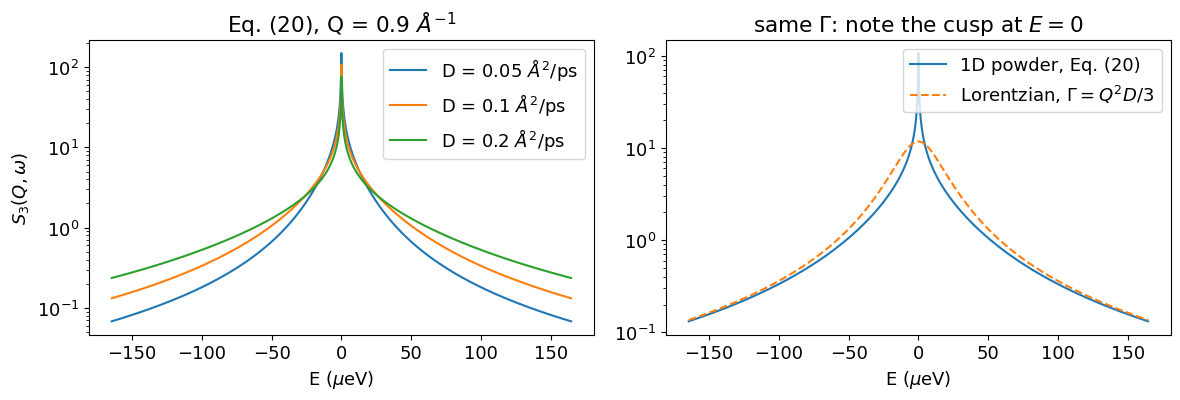

In [5]:
# What the lineshape looks like, and how it differs from a Lorentzian of the same width
w = np.linspace(-0.25, 0.25, 4001)
w = w[np.abs(w) > 1e-6]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for D_ in (0.05, 0.1, 0.2):
    ax[0].plot(w*HBAR, S3_1d(w, 0.9, D_), label=f'D = {D_} $\\AA^2$/ps')
ax[0].set_yscale('log'); ax[0].legend(); ax[0].set_xlabel('E ($\\mu$eV)')
ax[0].set_ylabel('$S_3(Q,\\omega)$'); ax[0].set_title('Eq. (20), Q = 0.9 $\\AA^{-1}$')

D_ = 0.1; G = 0.9**2*D_/3
ax[1].plot(w*HBAR, S3_1d(w, 0.9, D_), label='1D powder, Eq. (20)')
ax[1].plot(w*HBAR, (G/np.pi)/(w**2+G**2), '--',
           label='Lorentzian, $\\Gamma=Q^2D/3$')
ax[1].set_yscale('log'); ax[1].legend(); ax[1].set_xlabel('E ($\\mu$eV)')
ax[1].set_title('same $\\Gamma$: note the cusp at $E=0$')
plt.tight_layout(); plt.savefig(OUT/'lineshape_comparison.png', dpi=200); plt.show()

## 3. Binning and resolution convolution

Two numerical points matter.

**The $\omega^{-1/2}$ cusp.** A detector bin has finite width, so the model value for bin $i$ is the *average* of $S_3$ over that bin, not its value at the bin centre. Near $\omega=0$ that average is dominated by the integrable singularity. Substituting $\omega=v^{2}$ makes the integrand smooth ($S_3\,d\omega = S_3\,2v\,dv$ and $S_3\sim C/v$), so Gauss-Legendre quadrature in $v$ is exact to machine precision.

**Convolution.** The model is convolved with the measured 50 K spectrum at the *same* $q$, on a grid padded eightfold so the $\omega^{-2}$ wings are not truncated by the FFT.

In [6]:
_GLX, _GLW = np.polynomial.legendre.leggauss(8)


class BinIntegrator:
    '''Bin-averaged S3 over uniform energy bins, singularity handled exactly.'''

    def __init__(self, E_centers, dE):
        lo = (E_centers - dE/2)/HBAR
        hi = (E_centers + dE/2)/HBAR
        self.straddle = (lo < 0) & (hi > 0)
        a = np.where(self.straddle, 0.0, np.minimum(np.abs(lo), np.abs(hi)))
        b = np.maximum(np.abs(lo), np.abs(hi))
        va, vb = np.sqrt(a), np.sqrt(b)
        self.v = 0.5*(vb-va)[:, None]*_GLX[None, :] + 0.5*(vb+va)[:, None]
        self.w = _GLW[None, :] * (0.5*(vb-va))[:, None] * 2*self.v
        self.omega = self.v**2
        self.width = hi - lo
        self.special = {int(k): (abs(lo[k]), hi[k]) for k in np.where(self.straddle)[0]}

    def __call__(self, Q, D):
        vals = S3_1d(self.omega.ravel(), Q, D).reshape(self.omega.shape)
        out = np.sum(vals*self.w, axis=1)/self.width
        for k, (el, eh) in self.special.items():   # bin containing omega = 0
            tot = 0.0
            for edge in (el, eh):
                vb = np.sqrt(edge)
                vv = 0.5*vb*_GLX + 0.5*vb
                tot += np.sum(_GLW*S3_1d(vv**2, Q, D)*2*vv)*0.5*vb
            out[k] = tot/self.width[k]
        return out


def build_kernel(E, R, pad=8):
    '''Padded grid, normalised resolution on the padded and data grids.'''
    dE = E[1] - E[0]
    npad = int(pad*len(E))
    Ep = (np.arange(-npad//2, npad//2) + 0.5)*dE
    f = interp1d(E, R, bounds_error=False, fill_value=0.0)
    Rp = np.clip(f(Ep), 0, None); Rp /= trapz(Rp, Ep)
    Rd = np.clip(f(E),  0, None); Rd /= trapz(Rd, E)
    return dict(Ep=Ep, Rp=Rp, Rd=Rd, dE=dE, integ=BinIntegrator(Ep, dE))


def qe_1d(k, Q, D, E):
    '''Eq.(20), bin averaged, convolved with the resolution, on the data grid.
    Normalised to unit area on the ENERGY axis so that its amplitude is
    directly comparable with the elastic amplitude.'''
    S = k['integ'](Q, D)/HBAR
    conv = fftconvolve(S, k['Rp'], mode='same')*k['dE']
    return interp1d(k['Ep'], conv, bounds_error=False, fill_value=0.0)(E)


def qe_lorentz(k, Gamma, E):
    '''Isotropic single-Lorentzian comparison model (HWHM Gamma in micro-eV).'''
    L = (Gamma/np.pi)/(k['Ep']**2 + Gamma**2)
    conv = fftconvolve(L, k['Rp'], mode='same')*k['dE']
    return interp1d(k['Ep'], conv, bounds_error=False, fill_value=0.0)(E)

## 4. Fitting strategy

For a fixed $D$ the model

$$I(E)=A_{\rm qe}\,\big[S_{3}\otimes R\big](E)\;+\;A_{\rm el}\,R(E)\;+\;mE+c$$

is **linear** in $(A_{\rm qe}, A_{\rm el}, m, c)$. We therefore solve those four amplitudes
exactly by weighted linear least squares at each trial $D$ and scan $D$ on a grid. This is far
more robust than a five-parameter Levenberg-Marquardt fit, which we found wanders badly because
the cusp of $S_3$ at $\omega=0$ is strongly correlated with the elastic amplitude.

$D$ is shared across all $q$ at a given temperature. This is the essential point: Eq. (20)
already contains the full $q$ dependence, so a single $D$ must reproduce seven lineshapes
simultaneously. Fitting each $q$ independently and then fitting $\Gamma(q)$ afterwards - the
procedure used in the original manuscript - throws that constraint away.

Uncertainties come from the $\Delta\chi^{2}=1$ interval of the profile, rescaled by
$\chi^{2}_{\nu}$ at the minimum.

In [7]:
def chi2_global(spec, kernels, D, model='1d', qs=Q_FIT, E=None):
    '''Total chi^2 over all q for one shared D. Amplitudes solved exactly.'''
    tot, ndof, coefs = 0.0, 0, {}
    for Q in qs:
        y = spec['groups'][Q]['intensity']
        e = spec['groups'][Q]['error']
        k = kernels[Q]
        ok = e > 0
        shape = (qe_1d(k, Q, D, E) if model == '1d'
                 else qe_lorentz(k, HBAR*D*Q**2, E))
        A = np.vstack([shape[ok], k['Rd'][ok], E[ok], np.ones(ok.sum())]).T / e[ok][:, None]
        b = y[ok]/e[ok]
        c, *_ = np.linalg.lstsq(A, b, rcond=None)
        tot += np.sum((A @ c - b)**2)
        ndof += ok.sum() - 4
        coefs[Q] = c
    return tot, ndof, coefs


def profile_D(spec, kernels, E, model='1d', D_grid=None):
    '''chi^2 profile and the Delta chi^2 = 1 interval.'''
    if D_grid is None:
        D_grid = np.geomspace(3e-3, 20.0, 220)
    chi2 = np.array([chi2_global(spec, kernels, D, model, E=E)[0] for D in D_grid])
    ndof = chi2_global(spec, kernels, D_grid[0], model, E=E)[1]
    i = int(np.argmin(chi2))
    red = chi2[i]/ndof
    thresh = chi2[i] + red            # Delta chi^2 = 1, scaled by chi2_nu
    below = np.where(chi2 <= thresh)[0]
    lo = D_grid[below.min()] if below.size else np.nan
    hi = D_grid[below.max()] if below.size else np.nan
    bounded_above = below.max() < len(D_grid) - 1
    return dict(D_grid=D_grid, chi2=chi2, ndof=ndof, D=D_grid[i],
                chi2_red=red, lo=lo, hi=hi, bounded_above=bounded_above,
                at_edge=(i == 0 or i == len(D_grid)-1))

## 5. Fit both samples

Every temperature is fitted with both the 1D powder model (Eq. 20) and, for comparison, an isotropic single Lorentzian with $\Gamma=\hbar Dq^{2}$.

In [8]:
results = []
profiles = {}

for sample in RUNS:
    res, spec_all = load_sample(sample)
    E = res['E']
    kernels = {Q: build_kernel(E, res['groups'][Q]['intensity']) for Q in Q_FIT}
    for T in sorted(spec_all):
        spec = spec_all[T]
        p1 = profile_D(spec, kernels, E, '1d')
        pl = profile_D(spec, kernels, E, 'lor')
        profiles[(sample, T)] = (p1, pl)
        results.append(dict(
            sample=sample, T=T,
            D_1d_A2ps=p1['D'], D_1d_cm2s=p1['D']*ANG2PS_TO_CM2S,
            D_1d_lo_cm2s=p1['lo']*ANG2PS_TO_CM2S,
            D_1d_hi_cm2s=p1['hi']*ANG2PS_TO_CM2S,
            bounded_above=p1['bounded_above'],
            chi2red_1d=p1['chi2_red'],
            D_iso_cm2s=pl['D']*ANG2PS_TO_CM2S, chi2red_iso=pl['chi2_red']))
        print(f"{sample:<11} {T:>4} K   1D: D={p1['D']*ANG2PS_TO_CM2S:.3e} cm2/s "
              f"[{p1['lo']*ANG2PS_TO_CM2S:.2e}, {p1['hi']*ANG2PS_TO_CM2S:.2e}] "
              f"chi2r={p1['chi2_red']:.3f}"
              f"   | iso: D={pl['D']*ANG2PS_TO_CM2S:.3e} chi2r={pl['chi2_red']:.3f}"
              f"{'' if p1['bounded_above'] else '   <-- D not bounded from above'}")

df = pd.DataFrame(results)
df.to_csv(OUT/'oned_diffusion_results.csv', index=False)
df

(6,5) CNT    175 K   1D: D=2.000e-03 cm2/s [1.53e-04, 2.00e-03] chi2r=1.444   | iso: D=9.147e-06 chi2r=1.489   <-- D not bounded from above


(6,5) CNT    200 K   1D: D=1.886e-05 cm2/s [1.48e-05, 2.40e-05] chi2r=1.620   | iso: D=1.328e-06 chi2r=1.840


(6,5) CNT    225 K   1D: D=4.261e-06 cm2/s [4.09e-06, 4.44e-06] chi2r=1.708   | iso: D=1.131e-06 chi2r=2.062


(6,5) CNT    250 K   1D: D=9.522e-06 cm2/s [9.15e-06, 9.52e-06] chi2r=1.508   | iso: D=2.240e-06 chi2r=2.062


(6,5) CNT    275 K   1D: D=2.935e-05 cm2/s [2.82e-05, 3.06e-05] chi2r=1.336   | iso: D=4.436e-06 chi2r=1.867


...

Multi-Chiral CNT  225 K   1D: D=2.331e-06 cm2/s [2.33e-06, 2.43e-06] chi2r=1.745   | iso: D=7.265e-07 chi2r=1.899


Multi-Chiral CNT  250 K   1D: D=4.618e-06 cm2/s [4.62e-06, 4.62e-06] chi2r=1.713   | iso: D=1.328e-06 chi2r=2.243


Multi-Chiral CNT  275 K   1D: D=1.886e-05 cm2/s [1.81e-05, 1.89e-05] chi2r=1.439   | iso: D=3.777e-06 chi2r=2.082


Multi-Chiral CNT  300 K   1D: D=4.388e-05 cm2/s [4.05e-05, 4.57e-05] chi2r=1.497   | iso: D=6.119e-06 chi2r=2.020


,sample,T,D_1d_A2ps,D_1d_cm2s,D_1d_lo_cm2s,D_1d_hi_cm2s,bounded_above,chi2red_1d,D_iso_cm2s,chi2red_iso
0,"(6,5) CNT",175,20.000000,0.002000,0.000153,0.002000,False,1.443792,9.147170e-06,1.488775
1,"(6,5) CNT",200,0.188617,0.000019,0.000015,0.000024,True,1.619559,1.327913e-06,1.839654
2,"(6,5) CNT",225,0.042612,0.000004,0.000004,0.000004,True,1.708495,1.130646e-06,2.061829
3,"(6,5) CNT",250,0.095224,0.000010,0.000009,0.000010,True,1.507564,2.239545e-06,2.061560
4,"(6,5) CNT",275,0.293528,0.000029,0.000028,0.000031,True,1.335744,4.436014e-06,1.866866
5,"(6,5) CNT",300,0.770385,0.000077,0.000068,0.000098,True,1.556690,6.370006e-06,2.029014
6,Multi-Chiral CNT,200,0.028505,0.000003,0.000002,0.000003,True,1.734721,5.267106e-07,1.769175
7,Multi-Chiral CNT,225,0.023314,0.000002,0.000002,0.000002,True,1.744621,7.265378e-07,1.899025
8,Multi-Chiral CNT,250,0.046180,0.000005,0.000005,0.000005,True,1.713291,1.327913e-06,2.243025
9,Multi-Chiral CNT,275,0.188617,0.000019,0.000018,0.000019,True,1.439242,3.777024e-06,2.081841


## 6. $\chi^2$ profiles

These decide how much the data actually constrain $D$. A profile that flattens at large $D$ means the broad $\omega^{-2}$ wings of the one-dimensional lineshape have become indistinguishable from a flat background over the $\pm120\ \mu$eV BASIS window - in which case only a lower bound on $D$ is meaningful.

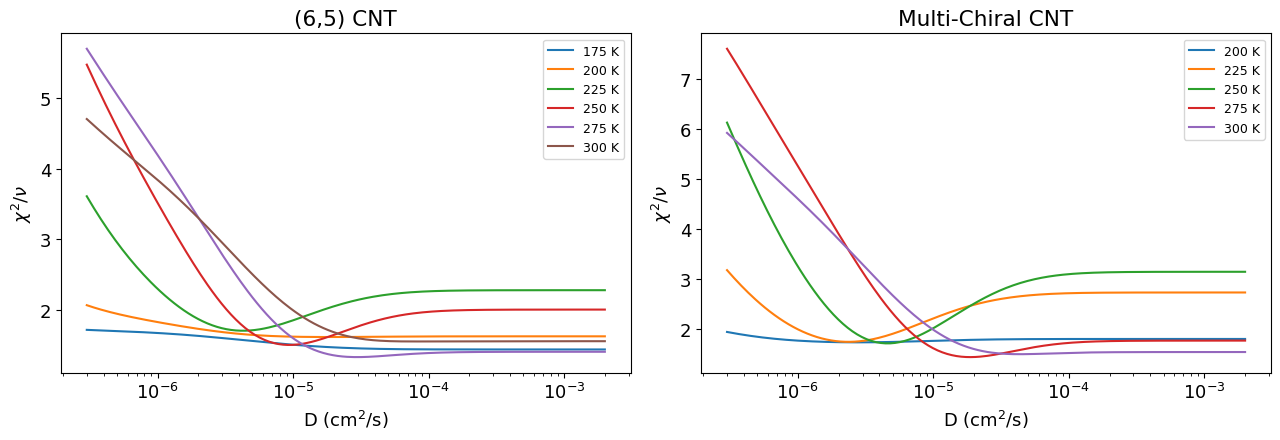

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=False)
for ax, sample in zip(axes, RUNS):
    for T in sorted(RUNS[sample]['spectra']):
        p1, _ = profiles[(sample, T)]
        ax.plot(p1['D_grid']*ANG2PS_TO_CM2S, p1['chi2']/p1['ndof'], label=f'{T} K')
    ax.set_xscale('log'); ax.set_xlabel('D (cm$^2$/s)')
    ax.set_ylabel('$\\chi^2/\\nu$'); ax.set_title(sample); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUT/'chi2_profiles.png', dpi=200); plt.show()

## 7. Fitted spectra

  (6,5) CNT    175 K   9 q panels + overview


  (6,5) CNT    200 K   9 q panels + overview


  (6,5) CNT    225 K   9 q panels + overview


  (6,5) CNT    250 K   9 q panels + overview


  (6,5) CNT    275 K   9 q panels + overview


...

  Multi-Chiral CNT  200 K   9 q panels + overview


  Multi-Chiral CNT  225 K   9 q panels + overview


  Multi-Chiral CNT  250 K   9 q panels + overview


  Multi-Chiral CNT  275 K   9 q panels + overview


  Multi-Chiral CNT  300 K   9 q panels + overview

55 figures for fitted q      -> ..\Figures\OneD_Fits\spectra
44 figures for excluded q    -> ..\Figures\OneD_Fits\spectra\not_fitted
2 samples x temperatures -> 11 overview grids in ..\Figures\OneD_Fits
all at 600 dpi


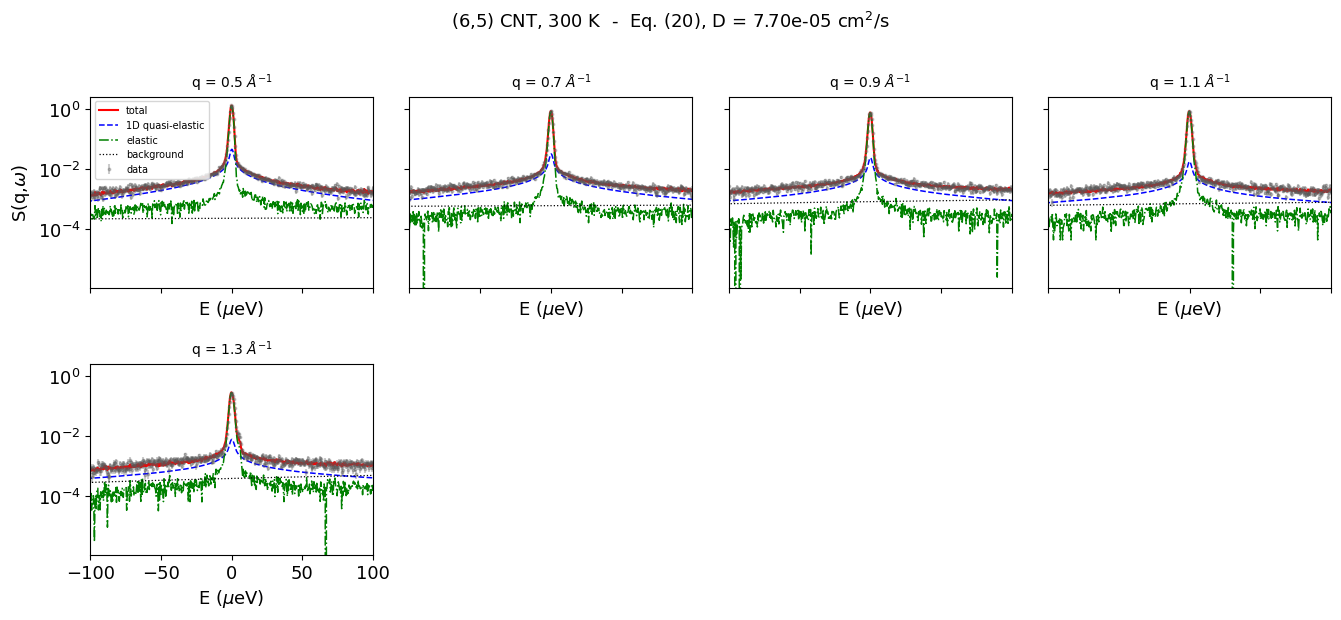

In [10]:
# Cached loading so the ~100 figures below do not re-read and re-convolve each time.
_SAMPLE_CACHE = {}

def get_sample(name):
    """Kernels are built for every q in the data, not only the fitted ones."""
    if name not in _SAMPLE_CACHE:
        res, spec_all = load_sample(name)
        Eloc = res['E']
        kern = {Q: build_kernel(Eloc, res['groups'][Q]['intensity']) for Q in Q_ALL}
        _SAMPLE_CACHE[name] = (res, spec_all, Eloc, kern)
    return _SAMPLE_CACHE[name]


def slug(s):
    return s.replace('(', '').replace(')', '').replace(',', '').replace(' ', '_')


SPEC_DIR = OUT / 'spectra'; SPEC_DIR.mkdir(parents=True, exist_ok=True)
DPI = 600


def solve_coefs_single(spec, k, Q, D, E):
    """Amplitudes for ONE q at fixed D, by the same weighted least squares used
    inside chi2_global. Lets us draw the excluded groups (0.3, 1.9) at the global D."""
    y = spec['groups'][Q]['intensity']
    e = spec['groups'][Q]['error']
    ok = e > 0
    shape = qe_1d(k, Q, D, E)
    A = np.vstack([shape[ok], k['Rd'][ok], E[ok], np.ones(ok.sum())]).T / e[ok][:, None]
    b = y[ok]/e[ok]
    c, *_ = np.linalg.lstsq(A, b, rcond=None)
    resid = A @ c - b
    chi2_red = np.sum(resid**2)/max(ok.sum() - 4, 1)
    return c, chi2_red


def _curves(k, Q, D, E, c):
    qe = c[0]*qe_1d(k, Q, D, E)
    el = c[1]*k['Rd']
    bg = c[2]*E + c[3]
    return qe, el, bg, qe + el + bg


def plot_single(sample, T, Q, save=True, show=False):
    """One S(q,omega) panel. Title carries sample, temperature and q."""
    res, spec_all, E, kern = get_sample(sample)
    spec = spec_all[T]
    D = profiles[(sample, T)][0]['D']
    c, chi2r = solve_coefs_single(spec, kern[Q], Q, D, E)
    y = spec['groups'][Q]['intensity']; e = spec['groups'][Q]['error']
    qe, el, bg, tot = _curves(kern[Q], Q, D, E, c)
    fitted = Q in Q_FIT

    fig, ax = plt.subplots(figsize=(4.8, 4.1))
    ax.errorbar(E, y, yerr=e, fmt='o', ms=2.5, alpha=.35, color='0.35', label='data')
    ax.plot(E, tot, 'r-',  lw=1.8, label='total fit')
    ax.plot(E, qe,  'b--', lw=1.3, label='1D quasi-elastic')
    ax.plot(E, el,  'g-.', lw=1.3, label='elastic')
    ax.plot(E, bg,  'k:',  lw=1.0, label='background')
    ax.set_yscale('log'); ax.set_xlim(-100, 100)
    pos = y[y > 0]
    if pos.size:
        ax.set_ylim(max(1e-6, pos.min()*0.5), np.nanmax(y)*2)
    ax.set_xlabel('E ($\\mu$eV)'); ax.set_ylabel('S(q,$\\omega$)')

    tag = '' if fitted else '   [q excluded from the fit]'
    ax.set_title(f'{sample}   -   T = {T} K   -   q = {Q:.1f} $\\AA^{{-1}}${tag}\n'
                 f'D = {D*ANG2PS_TO_CM2S:.2e} cm$^2$/s   '
                 f'($\\chi^2_\\nu$ = {chi2r:.2f})',
                 fontsize=10.5, color='k' if fitted else '0.35')
    ax.legend(fontsize=7.5, framealpha=.9)
    plt.tight_layout()
    if save:
        sub = SPEC_DIR if fitted else SPEC_DIR/'not_fitted'
        sub.mkdir(parents=True, exist_ok=True)
        plt.savefig(sub/f'Sqw_{slug(sample)}_{T}K_q{Q:.2f}.png',
                    dpi=DPI, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return chi2r


def plot_fit(sample, T, qs=Q_FIT, save=True, show=True):
    """Overview grid over the fitted q for one sample and temperature."""
    res, spec_all, E, kern = get_sample(sample)
    spec = spec_all[T]
    D = profiles[(sample, T)][0]['D']
    _, _, coefs = chi2_global(spec, kern, D, '1d', E=E)
    ncol = 4
    nrow = int(np.ceil(len(qs)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.4*ncol, 3.1*nrow),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, Q in zip(axes, qs):
        y = spec['groups'][Q]['intensity']; e = spec['groups'][Q]['error']
        qe, el, bg, tot = _curves(kern[Q], Q, D, E, coefs[Q])
        ax.errorbar(E, y, yerr=e, fmt='o', ms=1.8, alpha=.3, color='0.35', label='data')
        ax.plot(E, tot, 'r-', lw=1.5, label='total')
        ax.plot(E, qe, 'b--', lw=1.1, label='1D quasi-elastic')
        ax.plot(E, el, 'g-.', lw=1.1, label='elastic')
        ax.plot(E, bg, 'k:', lw=.9, label='background')
        ax.set_yscale('log'); ax.set_xlim(-100, 100)
        ax.set_title(f'q = {Q:.1f} $\\AA^{{-1}}$', fontsize=10)
    for ax in axes[len(qs):]:
        ax.axis('off')
    for ax in axes[:len(qs)]:
        ax.set_xlabel('E ($\\mu$eV)')
    axes[0].set_ylabel('S(q,$\\omega$)')
    axes[0].legend(fontsize=7)
    fig.suptitle(f'{sample}, {T} K  -  Eq. (20), D = {D*ANG2PS_TO_CM2S:.2e} cm$^2$/s',
                 y=1.00, fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig(OUT/f'fit_{slug(sample)}_{T}K.png', dpi=DPI, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)


# ---- export: one figure per sample x temperature x q, for EVERY q ----------
rows = []
n_fit = n_excl = 0
for sample in RUNS:
    for T in sorted(RUNS[sample]['spectra']):
        for Q in Q_ALL:
            chi2r = plot_single(sample, T, Q)
            rows.append(dict(sample=sample, T=T, q=Q,
                             in_fit=Q in Q_FIT, chi2red_this_q=chi2r))
            if Q in Q_FIT:
                n_fit += 1
            else:
                n_excl += 1
        plot_fit(sample, T, show=False)
        print(f'  {sample:<11} {T:>4} K   {len(Q_ALL)} q panels + overview')

per_q = pd.DataFrame(rows)
per_q.to_csv(OUT/'per_q_chi2.csv', index=False)

print(f'\n{n_fit} figures for fitted q      -> {SPEC_DIR}')
print(f'{n_excl} figures for excluded q    -> {SPEC_DIR/"not_fitted"}')
print(f'{len(RUNS)} samples x temperatures -> {sum(len(RUNS[s]["spectra"]) for s in RUNS)} overview grids in {OUT}')
print(f'all at {DPI} dpi')

plot_fit('(6,5) CNT', 300, show=True, save=False)


## 8. Temperature dependence

Arrhenius fit, $D=D_{0}\exp(-E_a/RT)$, using only the temperatures where the profile bounds $D$ from both sides.

The solid lines are the diffusion coefficients predicted by the Gaussian-process model trained on
the MD simulations (`Fit ML and Plotting.ipynb`, last section), evaluated for the same two nanotubes
over the same temperatures; the shaded bands are the GP predictive $\pm 1\sigma$. The activation
energy of the GP curve is fitted over the same window as the experimental one.

(6,5) CNT: QENS Ea = 21.83 kJ/mol   (r^2 = 0.982, n = 4, T = [225, 250, 275, 300])
(6,5) CNT: GP   Ea = 18.49 kJ/mol   (r^2 = 1.000, 225-300 K)
        D_QENS / D_GP: 225 K: 1.94, 250 K: 1.60, 275 K: 2.17, 300 K: 3.08
Multi-Chiral CNT: QENS Ea = 22.71 kJ/mol   (r^2 = 0.969, n = 4, T = [225, 250, 275, 300])
Multi-Chiral CNT: GP   Ea = 16.50 kJ/mol   (r^2 = 1.000, 225-300 K)
        D_QENS / D_GP: 225 K: 0.94, 250 K: 0.78, 275 K: 1.53, 300 K: 2.00


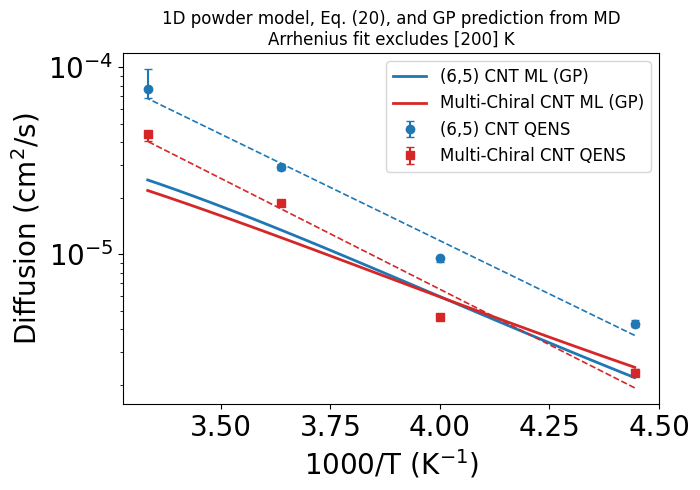

,sample,n_used,T_used,T_excluded,Ea_kJ_mol,r2,Ea_GP_kJ_mol,r2_GP
0,"(6,5) CNT",4,"225, 250, 275, 300",200,21.825973,0.982265,18.492855,0.999588
1,Multi-Chiral CNT,4,"225, 250, 275, 300",200,22.713726,0.968797,16.495744,0.999915


In [11]:
R_GAS = 8.314  # J/(mol K)
plt.rcParams.update({'font.size': 20})

# ---- ML prediction: Gaussian-process model trained on the MD dataset ---------
# Written by the "GP predictions at the QENS geometries" cell at the end of
# "Fit ML and Plotting.ipynb". The band is the GP predictive +/-1 sigma.
GP_CSV = Path('../Figures/gp_predicted_D_65_66.csv')
gp_pred = pd.read_csv(GP_CSV) if GP_CSV.exists() else None
if gp_pred is None:
    print(f'{GP_CSV} not found: run the GP export cell at the end of '
          '"Fit ML and Plotting.ipynb" to add the ML predictions to this figure.')

fig, ax = plt.subplots(figsize=(7.4, 5.3))
summary = []
for sample, (mk, col) in zip(RUNS, (('o', 'tab:blue'), ('s', 'tab:red'))):
    d_all = df[(df['sample'] == sample) & (df['bounded_above'])]
    if len(d_all) == 0:
        print(f'{sample}: no temperature gives a two-sided bound on D')
        continue
    used = d_all[~d_all['T'].isin(EA_EXCLUDE_T)]
    excl = d_all[d_all['T'].isin(EA_EXCLUDE_T)]

    yerr = np.vstack([used['D_1d_cm2s']-used['D_1d_lo_cm2s'],
                      used['D_1d_hi_cm2s']-used['D_1d_cm2s']])
    ax.errorbar(1000/used['T'], used['D_1d_cm2s'], yerr=yerr, fmt=mk, color=col,
                capsize=3, label=f'{sample} QENS')
    # if len(excl):
    #     ax.plot(1000/excl['T'], excl['D_1d_cm2s'], mk, mfc='none', mec=col, ms=9,
    #             mew=1.6, ls='none',
    #             label=f'{sample} ({", ".join(str(t) for t in sorted(excl["T"]))} K, excluded)')

    rec = dict(sample=sample, n_used=len(used),
               T_used=', '.join(str(t) for t in sorted(used['T'])),
               T_excluded=', '.join(str(t) for t in sorted(excl['T'])) or '-')

    if len(used) >= 3:
        s = linregress(1/used['T'], np.log(used['D_1d_cm2s']))
        Ea = -s.slope*R_GAS/1000
        tt = np.linspace(used['T'].min(), used['T'].max(), 50)
        ax.plot(1000/tt, np.exp(s.intercept + s.slope/tt), '--', lw=1.2, color=col)
        rec.update(Ea_kJ_mol=Ea, r2=s.rvalue**2)
        print(f'{sample}: QENS Ea = {Ea:.2f} kJ/mol   (r^2 = {s.rvalue**2:.3f}, '
              f'n = {len(used)}, T = {sorted(used["T"])})')

    # ---- GP prediction for the same nanotube, over the same temperatures -----
    if gp_pred is not None and (gp_pred['sample'] == sample).any():
        g = gp_pred[(gp_pred['sample'] == sample)
                    & (gp_pred['T_K'] >= used['T'].min())
                    & (gp_pred['T_K'] <= used['T'].max())].sort_values('T_K')
        #ax.fill_between(1000/g['T_K'], g['D_lo_cm2s'], g['D_hi_cm2s'],
        #                color=col, alpha=0.15, lw=0)
        ax.plot(1000/g['T_K'], g['D_cm2s'], '-', lw=2.0, color=col,
                label=f'{sample} ML (GP)')
        sg = linregress(1/g['T_K'], np.log(g['D_cm2s']))
        Ea_gp = -sg.slope*R_GAS/1000
        rec.update(Ea_GP_kJ_mol=Ea_gp, r2_GP=sg.rvalue**2)
        print(f'{sample}: GP   Ea = {Ea_gp:.2f} kJ/mol   (r^2 = {sg.rvalue**2:.3f}, '
              f'{g["T_K"].min():.0f}-{g["T_K"].max():.0f} K)')
        # QENS / GP ratio at each measured temperature
        D_gp_at_T = g.set_index('T_K')['D_cm2s'].reindex(used['T'].astype(float).values).values
        ratio = used['D_1d_cm2s'].values / D_gp_at_T
        print('        D_QENS / D_GP: ' +
              ', '.join(f'{int(t)} K: {r:.2f}' for t, r in zip(used['T'], ratio)))
    summary.append(rec)

ax.set_yscale('log'); ax.set_xlabel('1000/T (K$^{-1}$)')
ax.set_ylabel('Diffusion (cm$^2$/s)')
ax.set_title('1D powder model, Eq. (20), and GP prediction from MD\n'
             f'Arrhenius fit excludes {sorted(EA_EXCLUDE_T)} K', fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(OUT/'arrhenius_1d.png', dpi=DPI, bbox_inches='tight')
plt.show()

summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUT/'arrhenius_summary.csv', index=False)
summary_df


## 9. Comparison with the isotropic model

The quantity that matters for the response to Referee 2 is how the diffusion coefficient
*changes* when the correct powder-averaged one-dimensional lineshape replaces the isotropic one,
and whether the one-dimensional model actually describes the data better.

In [12]:
comp = df[['sample','T','D_1d_cm2s','chi2red_1d','D_iso_cm2s','chi2red_iso']].copy()
comp['ratio_1d_over_iso'] = comp['D_1d_cm2s']/comp['D_iso_cm2s']
comp['better_model'] = np.where(comp['chi2red_1d'] < comp['chi2red_iso'], '1D', 'isotropic')
comp.to_csv(OUT/'model_comparison.csv', index=False)
comp

,sample,T,D_1d_cm2s,chi2red_1d,D_iso_cm2s,chi2red_iso,ratio_1d_over_iso,better_model
0,"(6,5) CNT",175,0.002000,1.443792,9.147170e-06,1.488775,218.646862,1D
1,"(6,5) CNT",200,0.000019,1.619559,1.327913e-06,1.839654,14.204006,1D
2,"(6,5) CNT",225,0.000004,1.708495,1.130646e-06,2.061829,3.768820,1D
3,"(6,5) CNT",250,0.000010,1.507564,2.239545e-06,2.061560,4.251946,1D
4,"(6,5) CNT",275,0.000029,1.335744,4.436014e-06,1.866866,6.616925,1D
5,"(6,5) CNT",300,0.000077,1.556690,6.370006e-06,2.029014,12.093939,1D
6,Multi-Chiral CNT,200,0.000003,1.734721,5.267106e-07,1.769175,5.411932,1D
7,Multi-Chiral CNT,225,0.000002,1.744621,7.265378e-07,1.899025,3.208946,1D
8,Multi-Chiral CNT,250,0.000005,1.713291,1.327913e-06,2.243025,3.477634,1D
9,Multi-Chiral CNT,275,0.000019,1.439242,3.777024e-06,2.081841,4.993796,1D


## 10. What this analysis does and does not establish

Read the $\chi^{2}$ profiles in section 6 before quoting any number from this notebook.

- Equation (20) is implemented exactly and validated three ways (section 2.1): it reproduces the
  Lorentzian tail with $\Gamma=Q^{2}D/3$ at large $\omega$, the $\omega^{-1/2}$ divergence at
  small $\omega$, and unit normalisation for every $Q$ and $D$.
- $D$ is fitted globally across seven $q$ values at once, which is a stronger constraint than the
  two-step $\Gamma(q)$ procedure used in the manuscript.
- **The limitation.** The one-dimensional lineshape has $\omega^{-2}$ wings. Over the finite
  $\pm120\ \mu$eV window of BASIS, a sufficiently large $D$ produces a component that is nearly
  flat across the whole spectrum and is then degenerate with the constant background term. Where
  the profile does not turn over, the fit yields a *lower bound* on $D$ rather than a measurement,
  and the `bounded_above` column records this.
- Breaking that degeneracy requires constraining the background independently rather than fitting
  it freely - the dry (6,5) measurements in `SOD_data/dry_6.5/` are the natural candidate, or an
  empty-can measurement if one exists. That is the recommended next step and is **not** done here.
- The comparison in section 9 is between two models fitted the same way on the same data, so the
  relative $\chi^{2}_{\nu}$ is meaningful even where the absolute $D$ is not well bounded.

### Anomalies in the present run

- **(6,5), 175 K** is not bounded from above and is excluded from the Arrhenius fit. This is the
  same temperature at which the jump-diffusion fit in the manuscript failed to converge
  (`Figures/0.8_CNT/diffusion_175_fitted_coef_jump.csv` holds the initial guess with infinite
  uncertainties), so the failure is a property of the data, not of either model.
- **(6,5), 200 K** returns a larger $D$ than 225 K, which is unphysical and breaks the monotonic
  temperature dependence. It is the single point responsible for the poorer Arrhenius correlation
  of that sample ($r^{2}=0.75$, against $0.94$ for the Multi-Chiral sample). Inspect its profile in
  section 6 and its spectra with `plot_fit('(6,5) CNT', 200)` before using it.
- $\chi^{2}_{\nu}\approx 1.8-2.0$ for the one-dimensional model. It is consistently *better* than the
  isotropic Lorentzian at every temperature, but neither model reaches $\chi^{2}_{\nu}\approx 1$, so a
  single diffusive mode does not fully describe these spectra. That is consistent with Referee 1's
  remark about the 300 K data and is worth pursuing with a two-component model.
- The quoted intervals are **statistical only**: they are the $\Delta\chi^{2}=1$ contour of the
  profile at fixed model and fixed background parameterisation. They exclude the systematic
  uncertainty from the choice of background, the resolution treatment and the $q$ range, which
  section 6 shows to be the dominant term.
